In [1]:
# Cell 1: Enhanced Imports and Setup
# =========================================
# 🚀 Enhanced Deepfake Detection with Multiple Pretrained Models + Custom SENet
# Dataset: WildDeepfake (via KaggleHub)
# =========================================

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc, 
    precision_recall_curve, accuracy_score, precision_score, recall_score, f1_score
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    VGG16, VGG19, ResNet50, ResNet101, DenseNet121, EfficientNetB0, 
    EfficientNetB1, InceptionV3, MobileNetV2
)
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, ReLU, MaxPooling2D, AveragePooling2D,
    Dropout, GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Multiply, 
    Reshape, Add, Concatenate, Activation, Lambda
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1, l2
import warnings
warnings.filterwarnings('ignore')

# Enhanced GPU configuration
if tf.config.list_physical_devices('GPU'):
    try:
        gpu_devices = tf.config.list_physical_devices('GPU')
        for device in gpu_devices:
            tf.config.experimental.set_memory_growth(device, True)
        print(f"🎮 GPU memory growth enabled for {len(gpu_devices)} GPU(s)")
    except:
        print("💻 GPU available but memory growth not set")
else:
    print("💻 Running on CPU")

# Global storage for results
model_results = {}
history_dict = {}

print("✅ Enhanced imports and setup completed!")

2025-10-31 22:02:35.644369: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761948155.836861      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761948155.894313      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


🎮 GPU memory growth enabled for 1 GPU(s)
✅ Enhanced imports and setup completed!


In [2]:
# Cell 2: Enhanced Dataset Download and Setup
# =========================================
# 📂 Improved Dataset Management with Error Handling
# =========================================

def download_and_setup_dataset():
    """Enhanced dataset download with comprehensive error handling"""
    try:
        # Install kagglehub if needed
        try:
            import kagglehub
        except ImportError:
            print("📦 Installing kagglehub...")
            import subprocess
            import sys
            subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub"])
            import kagglehub
        
        print("⬇️ Downloading WildDeepfake dataset...")
        download_path = kagglehub.dataset_download("maysuni/wild-deepfake")
        print(f"✅ Dataset downloaded at: {download_path}")
        
        # Find the correct directory containing 'fake' and 'real' folders
        dataset_path = download_path
        for root, dirs, files in os.walk(download_path):
            if 'fake' in dirs and 'real' in dirs:
                dataset_path = root
                break
        
        # Handle zip extraction if needed
        for file in os.listdir(download_path):
            if file.endswith(".zip"):
                zip_path = os.path.join(download_path, file)
                extract_dir = os.path.join(download_path, "WildDeepfake")
                if not os.path.exists(extract_dir):
                    print("📦 Extracting dataset...")
                    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                        zip_ref.extractall(extract_dir)
                    print("✅ Dataset extracted successfully")
                dataset_path = extract_dir
                break
                
        # Verify dataset structure
        fake_dir = os.path.join(dataset_path, "fake")
        real_dir = os.path.join(dataset_path, "real")
        
        if os.path.exists(fake_dir) and os.path.exists(real_dir):
            fake_count = len([f for f in os.listdir(fake_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            real_count = len([f for f in os.listdir(real_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f"📊 Dataset verification:")
            print(f"   - Fake images: {fake_count}")
            print(f"   - Real images: {real_count}")
            print(f"   - Total images: {fake_count + real_count}")
            print(f"   - Dataset balance: {fake_count/(fake_count+real_count):.2%} fake, {real_count/(fake_count+real_count):.2%} real")
        else:
            raise FileNotFoundError("Could not find 'fake' and 'real' directories")
        
        return dataset_path
        
    except Exception as e:
        print(f"❌ Error setting up dataset: {str(e)}")
        print("💡 Please manually download the dataset and update the path")
        return None

# Download and setup dataset
dataset_path = download_and_setup_dataset()

⬇️ Downloading WildDeepfake dataset...
✅ Dataset downloaded at: /kaggle/input/wild-deepfake
📊 Dataset verification:
   - Fake images: 9180
   - Real images: 8168
   - Total images: 17348
   - Dataset balance: 52.92% fake, 47.08% real


In [3]:
# Cell 3: Enhanced Data Generators with Advanced Augmentation
# =========================================
# 🔧 Improved Data Preprocessing and Augmentation Strategies
# =========================================

def setup_enhanced_data_generators(dataset_path, img_size=(224, 224), batch_size=32, validation_split=0.2):
    """Setup enhanced data generators with advanced augmentation"""
    if dataset_path is None:
        return None, None
    
    try:
        # More sophisticated data augmentation for better generalization
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=30,           # Increased rotation
            width_shift_range=0.25,      # Increased shift range
            height_shift_range=0.25,
            shear_range=0.2,
            zoom_range=0.2,
            brightness_range=[0.7, 1.3], # Brightness variation
            horizontal_flip=True,
            vertical_flip=False,         # Usually not good for faces
            fill_mode='reflect',         # Better fill mode
            channel_shift_range=0.1,     # Color channel shifts
            validation_split=validation_split
        )

        # Simple rescaling for validation (no augmentation)
        val_datagen = ImageDataGenerator(
            rescale=1./255,
            validation_split=validation_split
        )

        # Create training generator
        train_gen = train_datagen.flow_from_directory(
            dataset_path,
            target_size=img_size,
            batch_size=batch_size,
            class_mode='binary',
            subset='training',
            shuffle=True,
            seed=42,
            interpolation='bicubic'  # Better interpolation
        )

        # Create validation generator
        val_gen = val_datagen.flow_from_directory(
            dataset_path,
            target_size=img_size,
            batch_size=batch_size,
            class_mode='binary',
            subset='validation',
            shuffle=False,
            seed=42,
            interpolation='bicubic'
        )

        print(f"✅ Enhanced data generators created:")
        print(f"   - Training samples: {train_gen.samples}")
        print(f"   - Validation samples: {val_gen.samples}")
        print(f"   - Class indices: {train_gen.class_indices}")
        print(f"   - Batch size: {batch_size}")
        print(f"   - Image size: {img_size}")
        print(f"   - Validation split: {validation_split}")
        
        return train_gen, val_gen
        
    except Exception as e:
        print(f"❌ Error creating data generators: {str(e)}")
        return None, None

# Setup data generators with optimized parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 24  # Optimized batch size for better gradient updates
VALIDATION_SPLIT = 0.2

train_gen, val_gen = setup_enhanced_data_generators(
    dataset_path, 
    img_size=IMG_SIZE, 
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT
)

Found 13879 images belonging to 2 classes.
Found 3469 images belonging to 2 classes.
✅ Enhanced data generators created:
   - Training samples: 13879
   - Validation samples: 3469
   - Class indices: {'fake': 0, 'real': 1}
   - Batch size: 24
   - Image size: (224, 224)
   - Validation split: 0.2


In [4]:
# Cell 4: Fixed Custom Modules (SE Block + CBAM) - KERAS TENSOR COMPATIBLE
# =========================================
# 🧠 Fixed Attention Mechanisms Compatible with Keras Functional API
# =========================================

class EnhancedSEBlock(tf.keras.layers.Layer):
    """Enhanced SE Block as a proper Keras Layer"""
    def __init__(self, ratio=16, name=None, **kwargs):
        super(EnhancedSEBlock, self).__init__(name=name, **kwargs)
        self.ratio = ratio
        
    def build(self, input_shape):
        self.filters = input_shape[-1]
        
        # Build squeeze layers
        self.gap = GlobalAveragePooling2D(name=f'{self.name}_avg_pool')
        self.gmp = GlobalMaxPooling2D(name=f'{self.name}_max_pool')
        
        # Build excitation layers
        self.reshape_avg = Reshape((1, 1, self.filters), name=f'{self.name}_avg_reshape')
        self.reshape_max = Reshape((1, 1, self.filters), name=f'{self.name}_max_reshape')
        
        # Dense layers for average path
        self.dense1_avg = Dense(self.filters // self.ratio, activation='relu', 
                               kernel_regularizer=l2(1e-4), name=f'{self.name}_avg_dense1')
        self.dropout_avg = Dropout(0.1, name=f'{self.name}_avg_dropout')
        self.dense2_avg = Dense(self.filters, activation='sigmoid', name=f'{self.name}_avg_dense2')
        
        # Dense layers for max path
        self.dense1_max = Dense(self.filters // self.ratio, activation='relu',
                               kernel_regularizer=l2(1e-4), name=f'{self.name}_max_dense1')
        self.dropout_max = Dropout(0.1, name=f'{self.name}_max_dropout')
        self.dense2_max = Dense(self.filters, activation='sigmoid', name=f'{self.name}_max_dense2')
        
        # Combine layers
        self.add_excite = Add(name=f'{self.name}_add')
        self.multiply = Multiply(name=f'{self.name}_multiply')
        
        super(EnhancedSEBlock, self).build(input_shape)
    
    def call(self, inputs, training=None):
        # Squeeze operations
        avg_pool = self.gap(inputs)
        max_pool = self.gmp(inputs)
        
        # Reshape
        avg_pool = self.reshape_avg(avg_pool)
        max_pool = self.reshape_max(max_pool)
        
        # Excitation - average path
        avg_excite = self.dense1_avg(avg_pool)
        avg_excite = self.dropout_avg(avg_excite, training=training)
        avg_excite = self.dense2_avg(avg_excite)
        
        # Excitation - max path
        max_excite = self.dense1_max(max_pool)
        max_excite = self.dropout_max(max_excite, training=training)
        max_excite = self.dense2_max(max_excite)
        
        # Combine and apply
        se_feature = self.add_excite([avg_excite, max_excite])
        se_feature = se_feature * 0.5  # Normalize
        
        return self.multiply([inputs, se_feature])
    
    def get_config(self):
        config = super(EnhancedSEBlock, self).get_config()
        config.update({'ratio': self.ratio})
        return config

class CBAMBlock(tf.keras.layers.Layer):
    """CBAM Block as a proper Keras Layer"""
    def __init__(self, ratio=16, name=None, **kwargs):
        super(CBAMBlock, self).__init__(name=name, **kwargs)
        self.ratio = ratio
        
    def build(self, input_shape):
        self.filters = input_shape[-1]
        
        # Channel attention layers
        self.gap_ch = GlobalAveragePooling2D(keepdims=True, name=f'{self.name}_ch_avg')
        self.gmp_ch = GlobalMaxPooling2D(keepdims=True, name=f'{self.name}_ch_max')
        
        self.dense1_avg = Dense(self.filters // self.ratio, activation='relu', name=f'{self.name}_ch_dense1_avg')
        self.dense2_avg = Dense(self.filters, name=f'{self.name}_ch_dense2_avg')
        
        self.dense1_max = Dense(self.filters // self.ratio, activation='relu', name=f'{self.name}_ch_dense1_max')
        self.dense2_max = Dense(self.filters, name=f'{self.name}_ch_dense2_max')
        
        self.add_ch = Add(name=f'{self.name}_ch_add')
        self.sigmoid_ch = Activation('sigmoid', name=f'{self.name}_ch_sigmoid')
        self.multiply_ch = Multiply(name=f'{self.name}_ch_multiply')
        
        # Spatial attention layers
        self.concat_sp = Concatenate(axis=3, name=f'{self.name}_sp_concat')
        self.conv_sp = Conv2D(1, (7, 7), strides=1, padding='same', activation='sigmoid',
                             kernel_regularizer=l2(1e-4), name=f'{self.name}_sp_conv')
        self.multiply_sp = Multiply(name=f'{self.name}_sp_multiply')
        
        super(CBAMBlock, self).build(input_shape)
    
    def call(self, inputs, training=None):
        # Channel Attention
        avg_pool = self.gap_ch(inputs)
        max_pool = self.gmp_ch(inputs)
        
        avg_pool = self.dense1_avg(avg_pool)
        avg_pool = self.dense2_avg(avg_pool)
        
        max_pool = self.dense1_max(max_pool)
        max_pool = self.dense2_max(max_pool)
        
        channel_attention = self.add_ch([avg_pool, max_pool])
        channel_attention = self.sigmoid_ch(channel_attention)
        x = self.multiply_ch([inputs, channel_attention])
        
        # Spatial Attention
        avg_pool_spatial = tf.reduce_mean(x, axis=3, keepdims=True)
        max_pool_spatial = tf.reduce_max(x, axis=3, keepdims=True)
        
        spatial_attention = self.concat_sp([avg_pool_spatial, max_pool_spatial])
        spatial_attention = self.conv_sp(spatial_attention)
        
        output = self.multiply_sp([x, spatial_attention])
        
        return output
    
    def get_config(self):
        config = super(CBAMBlock, self).get_config()
        config.update({'ratio': self.ratio})
        return config

class ResidualBlock(tf.keras.layers.Layer):
    """Residual Block as a proper Keras Layer"""
    def __init__(self, filters, kernel_size=3, stride=1, name=None, **kwargs):
        super(ResidualBlock, self).__init__(name=name, **kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.stride = stride
        
    def build(self, input_shape):
        # Main path layers
        self.conv1 = Conv2D(self.filters, self.kernel_size, strides=self.stride, padding='same',
                           kernel_regularizer=l2(1e-4), name=f'{self.name}_conv1')
        self.bn1 = BatchNormalization(name=f'{self.name}_bn1')
        self.relu1 = ReLU(name=f'{self.name}_relu1')
        
        self.conv2 = Conv2D(self.filters, self.kernel_size, strides=1, padding='same',
                           kernel_regularizer=l2(1e-4), name=f'{self.name}_conv2')
        self.bn2 = BatchNormalization(name=f'{self.name}_bn2')
        
        # SE attention
        self.se_block = EnhancedSEBlock(ratio=16, name=f'{self.name}_se')
        
        # Shortcut layers (if needed)
        self.shortcut_conv = None
        self.shortcut_bn = None
        if self.stride != 1 or input_shape[-1] != self.filters:
            self.shortcut_conv = Conv2D(self.filters, 1, strides=self.stride, padding='same',
                                       name=f'{self.name}_shortcut')
            self.shortcut_bn = BatchNormalization(name=f'{self.name}_shortcut_bn')
        
        self.add = Add(name=f'{self.name}_add')
        self.relu2 = ReLU(name=f'{self.name}_relu2')
        
        super(ResidualBlock, self).build(input_shape)
    
    def call(self, inputs, training=None):
        shortcut = inputs
        
        # Main path
        x = self.conv1(inputs)
        x = self.bn1(x, training=training)
        x = self.relu1(x)
        
        x = self.conv2(x)
        x = self.bn2(x, training=training)
        
        # Apply SE attention
        x = self.se_block(x, training=training)
        
        # Shortcut connection
        if self.shortcut_conv is not None:
            shortcut = self.shortcut_conv(shortcut)
            shortcut = self.shortcut_bn(shortcut, training=training)
        
        x = self.add([x, shortcut])
        x = self.relu2(x)
        
        return x
    
    def get_config(self):
        config = super(ResidualBlock, self).get_config()
        config.update({
            'filters': self.filters,
            'kernel_size': self.kernel_size,
            'stride': self.stride
        })
        return config

# Helper functions for backward compatibility
def enhanced_se_block(x, ratio=16, name="se_block"):
    """Wrapper function for EnhancedSEBlock"""
    return EnhancedSEBlock(ratio=ratio, name=name)(x)

def cbam_block(x, ratio=16, name="cbam_block"):
    """Wrapper function for CBAMBlock"""
    return CBAMBlock(ratio=ratio, name=name)(x)

def residual_block(x, filters, kernel_size=3, stride=1, name="residual_block"):
    """Wrapper function for ResidualBlock"""
    return ResidualBlock(filters=filters, kernel_size=kernel_size, stride=stride, name=name)(x)

print("✅ Fixed attention modules as proper Keras Layers!")

✅ Fixed attention modules as proper Keras Layers!


In [5]:
# Cell 5: Enhanced Custom SENet Architecture
# =========================================
# 🏗️ Advanced Custom SENet with Multiple Attention Mechanisms
# =========================================

def build_enhanced_senet(input_shape=(224, 224, 3), num_classes=1):
    """Build enhanced SENet with CBAM and residual connections"""
    inputs = Input(shape=input_shape, name='input_layer')

    # Initial convolution
    x = Conv2D(64, (7, 7), strides=2, padding='same', 
              kernel_regularizer=l2(1e-4), name='initial_conv')(inputs)
    x = BatchNormalization(name='initial_bn')(x)
    x = ReLU(name='initial_relu')(x)
    x = MaxPooling2D((3, 3), strides=2, padding='same', name='initial_pool')(x)

    # Enhanced blocks with progressive feature extraction
    x = residual_block(x, 64, name='block1_1')
    x = residual_block(x, 64, name='block1_2')
    x = cbam_block(x, name='cbam1')

    x = residual_block(x, 128, stride=2, name='block2_1')
    x = residual_block(x, 128, name='block2_2')
    x = residual_block(x, 128, name='block2_3')
    x = cbam_block(x, name='cbam2')

    x = residual_block(x, 256, stride=2, name='block3_1')
    x = residual_block(x, 256, name='block3_2')
    x = residual_block(x, 256, name='block3_3')
    x = residual_block(x, 256, name='block3_4')
    x = cbam_block(x, name='cbam3')

    x = residual_block(x, 512, stride=2, name='block4_1')
    x = residual_block(x, 512, name='block4_2')
    x = enhanced_se_block(x, ratio=16, name='final_se')

    # Advanced classifier head
    gap = GlobalAveragePooling2D(name='global_avg_pool')(x)
    gmp = GlobalMaxPooling2D(name='global_max_pool')(x)
    x = Concatenate(name='pool_concat')([gap, gmp])

    # Multi-layer classifier with regularization
    x = Dense(512, activation='relu', kernel_regularizer=l2(1e-3), name='fc1')(x)
    x = BatchNormalization(name='fc1_bn')(x)
    x = Dropout(0.5, name='dropout1')(x)

    x = Dense(256, activation='relu', kernel_regularizer=l2(1e-3), name='fc2')(x)
    x = BatchNormalization(name='fc2_bn')(x)
    x = Dropout(0.4, name='dropout2')(x)

    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-3), name='fc3')(x)
    x = Dropout(0.3, name='dropout3')(x)

    # Output layer
    if num_classes == 1:
        output = Dense(1, activation='sigmoid', name='output')(x)
    else:
        output = Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inputs, outputs=output, name='Enhanced_SENet')
    return model

def build_lightweight_senet(input_shape=(224, 224, 3)):
    """Lightweight SENet for faster training"""
    inputs = Input(shape=input_shape, name='input_layer')

    # Lightweight architecture
    x = Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2(1e-4), name='conv1')(inputs)
    x = BatchNormalization(name='bn1')(x)
    x = ReLU(name='relu1')(x)
    x = enhanced_se_block(x, ratio=8, name='se1')
    x = MaxPooling2D((2, 2), name='pool1')(x)

    x = Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(1e-4), name='conv2')(x)
    x = BatchNormalization(name='bn2')(x)
    x = ReLU(name='relu2')(x)
    x = enhanced_se_block(x, ratio=8, name='se2')
    x = MaxPooling2D((2, 2), name='pool2')(x)

    x = Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(1e-4), name='conv3')(x)
    x = BatchNormalization(name='bn3')(x)
    x = ReLU(name='relu3')(x)
    x = enhanced_se_block(x, ratio=8, name='se3')
    x = MaxPooling2D((2, 2), name='pool3')(x)

    x = Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(1e-4), name='conv4')(x)
    x = BatchNormalization(name='bn4')(x)
    x = ReLU(name='relu4')(x)
    x = enhanced_se_block(x, ratio=16, name='se4')

    # Classifier
    x = GlobalAveragePooling2D(name='gap')(x)
    x = Dropout(0.5, name='dropout1')(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(1e-3), name='fc1')(x)
    x = Dropout(0.3, name='dropout2')(x)
    output = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inputs, outputs=output, name='Lightweight_SENet')
    return model

print("✅ Enhanced SENet architectures defined!")

✅ Enhanced SENet architectures defined!


In [6]:
# Cell 6: Enhanced Training and Evaluation Functions
# =========================================
# 🎯 Advanced Training Pipeline with Comprehensive Evaluation
# =========================================

def create_advanced_callbacks(model_name, patience=5):
    """Create advanced callbacks for better training control"""
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1,
            mode='min'
        ),
        
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1,
            mode='min'
        ),
        
        ModelCheckpoint(
            f'{model_name}_best.weights.h5',
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
            mode='max'
        )
    ]
    return callbacks

def evaluate_model_comprehensive(model, val_gen, model_name):
    """Comprehensive model evaluation with multiple metrics"""
    print(f"\n📊 Comprehensive Evaluation: {model_name}")
    print("=" * 50)
    
    # Get predictions
    val_gen.reset()
    y_true = val_gen.classes
    y_proba = model.predict(val_gen, verbose=0).flatten()
    
    # Calculate optimal threshold
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    
    # Predictions with different thresholds
    y_pred_default = (y_proba > 0.5).astype(int)
    y_pred_optimal = (y_proba > optimal_threshold).astype(int)
    
    # Calculate metrics
    metrics = {
        'model_name': model_name,
        'accuracy_default': accuracy_score(y_true, y_pred_default),
        'accuracy_optimal': accuracy_score(y_true, y_pred_optimal),
        'precision_default': precision_score(y_true, y_pred_default),
        'precision_optimal': precision_score(y_true, y_pred_optimal),
        'recall_default': recall_score(y_true, y_pred_default),
        'recall_optimal': recall_score(y_true, y_pred_optimal),
        'f1_default': f1_score(y_true, y_pred_default),
        'f1_optimal': f1_score(y_true, y_pred_optimal),
        'roc_auc': auc(fpr, tpr),
        'optimal_threshold': optimal_threshold
    }
    
    # Precision-Recall curve
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall_curve, precision_curve)
    metrics['pr_auc'] = pr_auc
    
    # Print results
    print(f"🎯 Default Threshold (0.5):")
    print(f"   Accuracy: {metrics['accuracy_default']:.4f}")
    print(f"   Precision: {metrics['precision_default']:.4f}")
    print(f"   Recall: {metrics['recall_default']:.4f}")
    print(f"   F1-Score: {metrics['f1_default']:.4f}")
    
    print(f"\n🎯 Optimal Threshold ({optimal_threshold:.3f}):")
    print(f"   Accuracy: {metrics['accuracy_optimal']:.4f}")
    print(f"   Precision: {metrics['precision_optimal']:.4f}")
    print(f"   Recall: {metrics['recall_optimal']:.4f}")
    print(f"   F1-Score: {metrics['f1_optimal']:.4f}")
    
    print(f"\n📈 Curve Metrics:")
    print(f"   ROC AUC: {metrics['roc_auc']:.4f}")
    print(f"   PR AUC: {metrics['pr_auc']:.4f}")
    
    # Store results
    model_results[model_name] = metrics
    
    return metrics, y_true, y_proba, fpr, tpr, precision_curve, recall_curve

def plot_model_performance(model_name, history, y_true, y_proba, fpr, tpr, precision_curve, recall_curve):
    """Plot comprehensive model performance"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Training history - Accuracy
    axes[0, 0].plot(history.history['accuracy'], 'b-', label='Training', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], 'r-', label='Validation', linewidth=2)
    axes[0, 0].set_title(f'{model_name} - Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Training history - Loss
    axes[0, 1].plot(history.history['loss'], 'b-', label='Training', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[0, 1].set_title(f'{model_name} - Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # ROC Curve
    roc_auc = auc(fpr, tpr)
    axes[0, 2].plot(fpr, tpr, 'b-', linewidth=3, label=f'ROC Curve (AUC = {roc_auc:.3f})')
    axes[0, 2].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Random Classifier')
    axes[0, 2].set_xlim([0.0, 1.0])
    axes[0, 2].set_ylim([0.0, 1.05])
    axes[0, 2].set_xlabel('False Positive Rate')
    axes[0, 2].set_ylabel('True Positive Rate')
    axes[0, 2].set_title('ROC Curve')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Precision-Recall Curve
    pr_auc = auc(recall_curve, precision_curve)
    axes[1, 0].plot(recall_curve, precision_curve, 'g-', linewidth=3, 
                    label=f'PR Curve (AUC = {pr_auc:.3f})')
    axes[1, 0].set_xlim([0.0, 1.0])
    axes[1, 0].set_ylim([0.0, 1.05])
    axes[1, 0].set_xlabel('Recall')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].set_title('Precision-Recall Curve')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Confusion Matrix
    y_pred = (y_proba > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1],
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    axes[1, 1].set_title('Confusion Matrix')
    axes[1, 1].set_ylabel('True Label')
    axes[1, 1].set_xlabel('Predicted Label')
    
    # Prediction Distribution
    axes[1, 2].hist(y_proba[y_true == 0], bins=30, alpha=0.7, label='Real', color='blue')
    axes[1, 2].hist(y_proba[y_true == 1], bins=30, alpha=0.7, label='Fake', color='red')
    axes[1, 2].axvline(x=0.5, color='black', linestyle='--', label='Threshold')
    axes[1, 2].set_xlabel('Prediction Probability')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].set_title('Prediction Distribution')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle(f'🚀 {model_name} - Comprehensive Performance Analysis', 
                 fontsize=16, y=1.02)
    plt.show()

print("✅ Enhanced training and evaluation functions ready!")

✅ Enhanced training and evaluation functions ready!


In [7]:
# Cell 7: Fixed Enhanced Model Training Pipeline  
# =========================================
# 🚀 Fixed Training Function Compatible with Keras Functional API
# =========================================

def build_and_train_enhanced_fixed(base_model_class, model_name, train_gen, val_gen, epochs=15):
    """Fixed enhanced training pipeline with proper Keras layers"""
    
    print(f"\n🚀 Training Enhanced {model_name}...")
    print("=" * 60)
    
    try:
        # Model creation based on type
        if model_name == "Enhanced_SENet":
            model = build_enhanced_senet(input_shape=IMG_SIZE + (3,))
            print(f"📋 Custom Enhanced SENet created with {model.count_params():,} parameters")
            
        elif model_name == "Lightweight_SENet":
            model = build_lightweight_senet(input_shape=IMG_SIZE + (3,))
            print(f"📋 Lightweight SENet created with {model.count_params():,} parameters")
            
        else:
            # Fixed pretrained model setup
            base_model = base_model_class(
                weights='imagenet', 
                include_top=False, 
                input_shape=IMG_SIZE + (3,)
            )
            
            # Fine-tuning strategy: freeze initially
            base_model.trainable = False
            
            # Create input layer
            inputs = Input(shape=IMG_SIZE + (3,), name='input_layer')
            
            # Pass through base model
            x = base_model(inputs, training=False)
            
            # Enhanced classifier head without problematic operations
            gap = GlobalAveragePooling2D(name='gap')(x)
            gmp = GlobalMaxPooling2D(name='gmp')(x)
            pooled_features = Concatenate(name='pool_concat')([gap, gmp])
            
            # Multi-layer classifier
            x = Dense(512, activation='relu', kernel_regularizer=l2(1e-3), name='fc1')(pooled_features)
            x = BatchNormalization(name='fc1_bn')(x)
            x = Dropout(0.5, name='dropout1')(x)
            
            x = Dense(256, activation='relu', kernel_regularizer=l2(1e-3), name='fc2')(x)
            x = Dropout(0.4, name='dropout2')(x)
            
            output = Dense(1, activation='sigmoid', name='output')(x)
            
            model = Model(inputs=inputs, outputs=output, name=f'Enhanced_{model_name}')
            print(f"📋 Enhanced {model_name} created with {model.count_params():,} parameters")

        # Advanced optimizer configuration
        initial_lr = 0.0001 if "SENet" in model_name else 0.0005
        optimizer = Adam(
            learning_rate=initial_lr,
            beta_1=0.9,
            beta_2=0.999,
            epsilon=1e-8
        )

        # Compile model with additional metrics
        model.compile(
            optimizer=optimizer,
            loss='binary_crossentropy',
            metrics=[
                'accuracy',
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall'),
                tf.keras.metrics.AUC(name='auc')
            ]
        )

        print(f"🔧 Training Configuration:")
        print(f"   - Optimizer: Adam (lr={initial_lr})")
        print(f"   - Epochs: {epochs}")
        print(f"   - Batch Size: {train_gen.batch_size}")
        print(f"   - Training Steps: {len(train_gen)}")
        print(f"   - Validation Steps: {len(val_gen)}")

        # Create callbacks
        callbacks = create_advanced_callbacks(model_name, patience=6)

        # Train model
        history = model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=epochs,
            callbacks=callbacks,
            verbose=1
        )

        # Store history
        history_dict[model_name] = history

        # Comprehensive evaluation
        metrics, y_true, y_proba, fpr, tpr, precision_curve, recall_curve = evaluate_model_comprehensive(
            model, val_gen, model_name
        )

        # Plot performance
        plot_model_performance(model_name, history, y_true, y_proba, fpr, tpr, 
                             precision_curve, recall_curve)

        print(f"✅ {model_name} training completed successfully!")
        
        return model, history, metrics

    except Exception as e:
        print(f"❌ Error training {model_name}: {str(e)}")
        import traceback
        print("Full error traceback:")
        print(traceback.format_exc())
        return None, None, None

print("✅ Fixed enhanced training pipeline ready!")

✅ Fixed enhanced training pipeline ready!



🚀 Starting VGG16 training...

🚀 Training Enhanced VGG16...


I0000 00:00:1761948212.140127      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
📋 Enhanced VGG16 created with 15,373,121 parameters
🔧 Training Configuration:
   - Optimizer: Adam (lr=0.0005)
   - Epochs: 12
   - Batch Size: 24
   - Training Steps: 579
   - Validation Steps: 145
Epoch 1/12


I0000 00:00:1761948219.443083     113 service.cc:148] XLA service 0x7b0c2c0119e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761948219.443897     113 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1761948220.020327     113 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/579 ━━━━━━━━━━━━━━━━━━━━ 39s 68ms/step - accuracy: 0.5417 - auc: 0.5428 - loss: 1.9688 - precision: 0.5147 - recall: 0.7614   

I0000 00:00:1761948227.932409     113 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.6012 - auc: 0.6399 - loss: 1.4449 - precision: 0.5743 - recall: 0.5809
Epoch 1: val_accuracy improved from -inf to 0.61228, saving model to VGG16_best.weights.h5
579/579 ━━━━━━━━━━━━━━━━━━━━ 271s 447ms/step - accuracy: 0.6012 - auc: 0.6400 - loss: 1.4445 - precision: 0.5744 - recall: 0.5809 - val_accuracy: 0.6123 - val_auc: 0.7437 - val_loss: 1.2460 - val_precision: 0.8692 - val_recall: 0.2076 - learning_rate: 5.0000e-04
Epoch 2/12
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.7061 - auc: 0.7721 - loss: 0.9913 - precision: 0.6985 - recall: 0.6774
Epoch 2: val_accuracy improved from 0.61228 to 0.63131, saving model to VGG16_best.weights.h5
579/579 ━━━━━━━━━━━━━━━━━━━━ 200s 345ms/step - accuracy: 0.7061 - auc: 0.7721 - loss: 0.9912 - precision: 0.6985 - recall: 0.6774 - val_accuracy: 0.6313 - val_auc: 0.7147 - val_loss: 1.0250 - val_precision: 0.5760 - val_recall: 0.8218 - learning_rate: 5.0000e-04
Epoch 3/12
579/579 ━━━

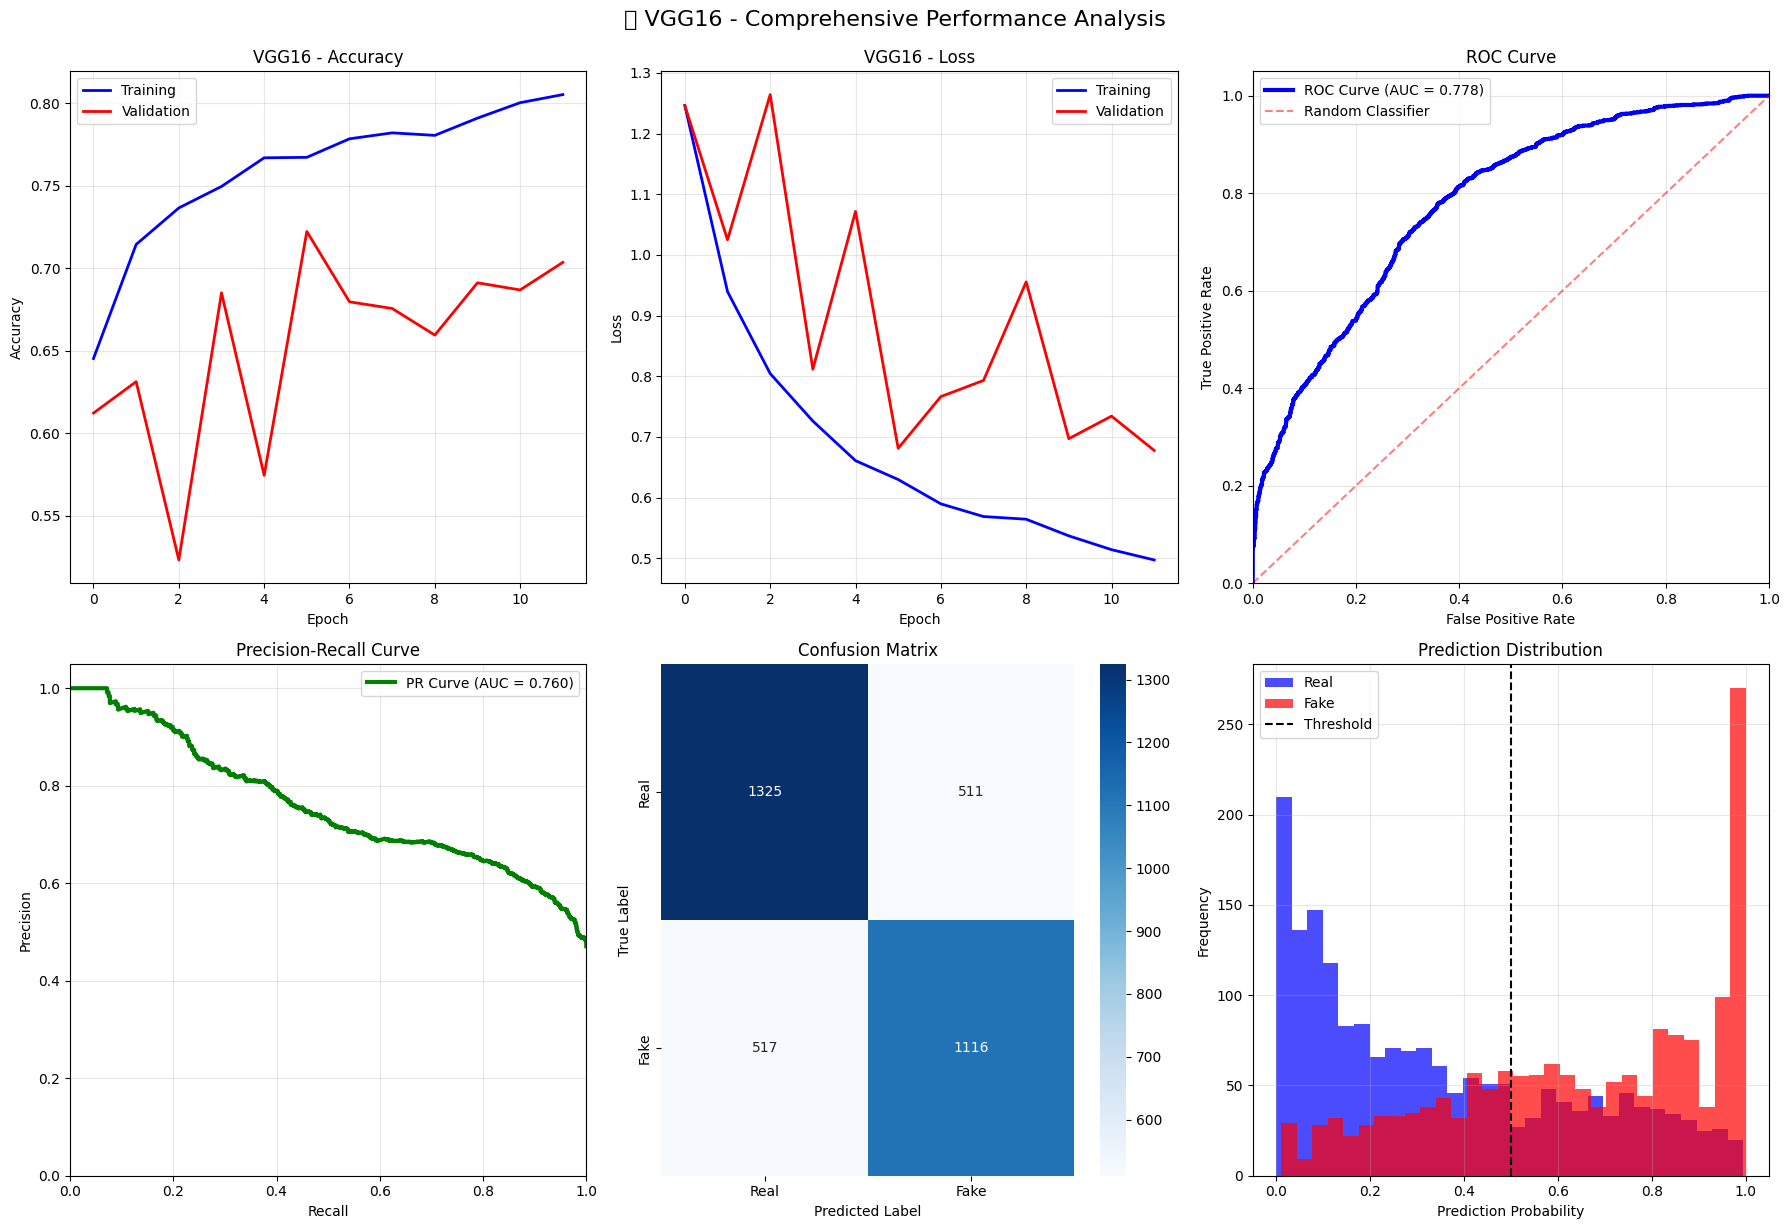

✅ VGG16 training completed successfully!
✅ VGG16 training completed successfully!
🧹 Memory cleared after VGG16

🚀 Starting VGG19 training...

🚀 Training Enhanced VGG19...
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
📋 Enhanced VGG19 created with 20,682,817 parameters
🔧 Training Configuration:
   - Optimizer: Adam (lr=0.0005)
   - Epochs: 12
   - Batch Size: 24
   - Training Steps: 579
   - Validation Steps: 145
Epoch 1/12
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.5998 - auc: 0.6412 - loss: 1.4517 - precision: 0.5800 - recall: 0.6030
Epoch 1: val_accuracy improved from -inf to 0.56010, saving model to VGG19_best.weights.h5
579/579 ━━━━━━━━━━━━━━━━━━━━ 214s 357ms/step - accuracy: 0.5998 - auc: 0.6412 - loss: 1.4514 - precision: 0.5800 - recall: 0.6030 - val_accuracy: 0.5601 - val_auc: 0.6146 - val_loss: 1.2597 - val_precision: 0.5358 - val_recall: 0.4899 - learning_rate: 5.0000e-04
Epoch 2/12
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.6755 - auc: 0.7396

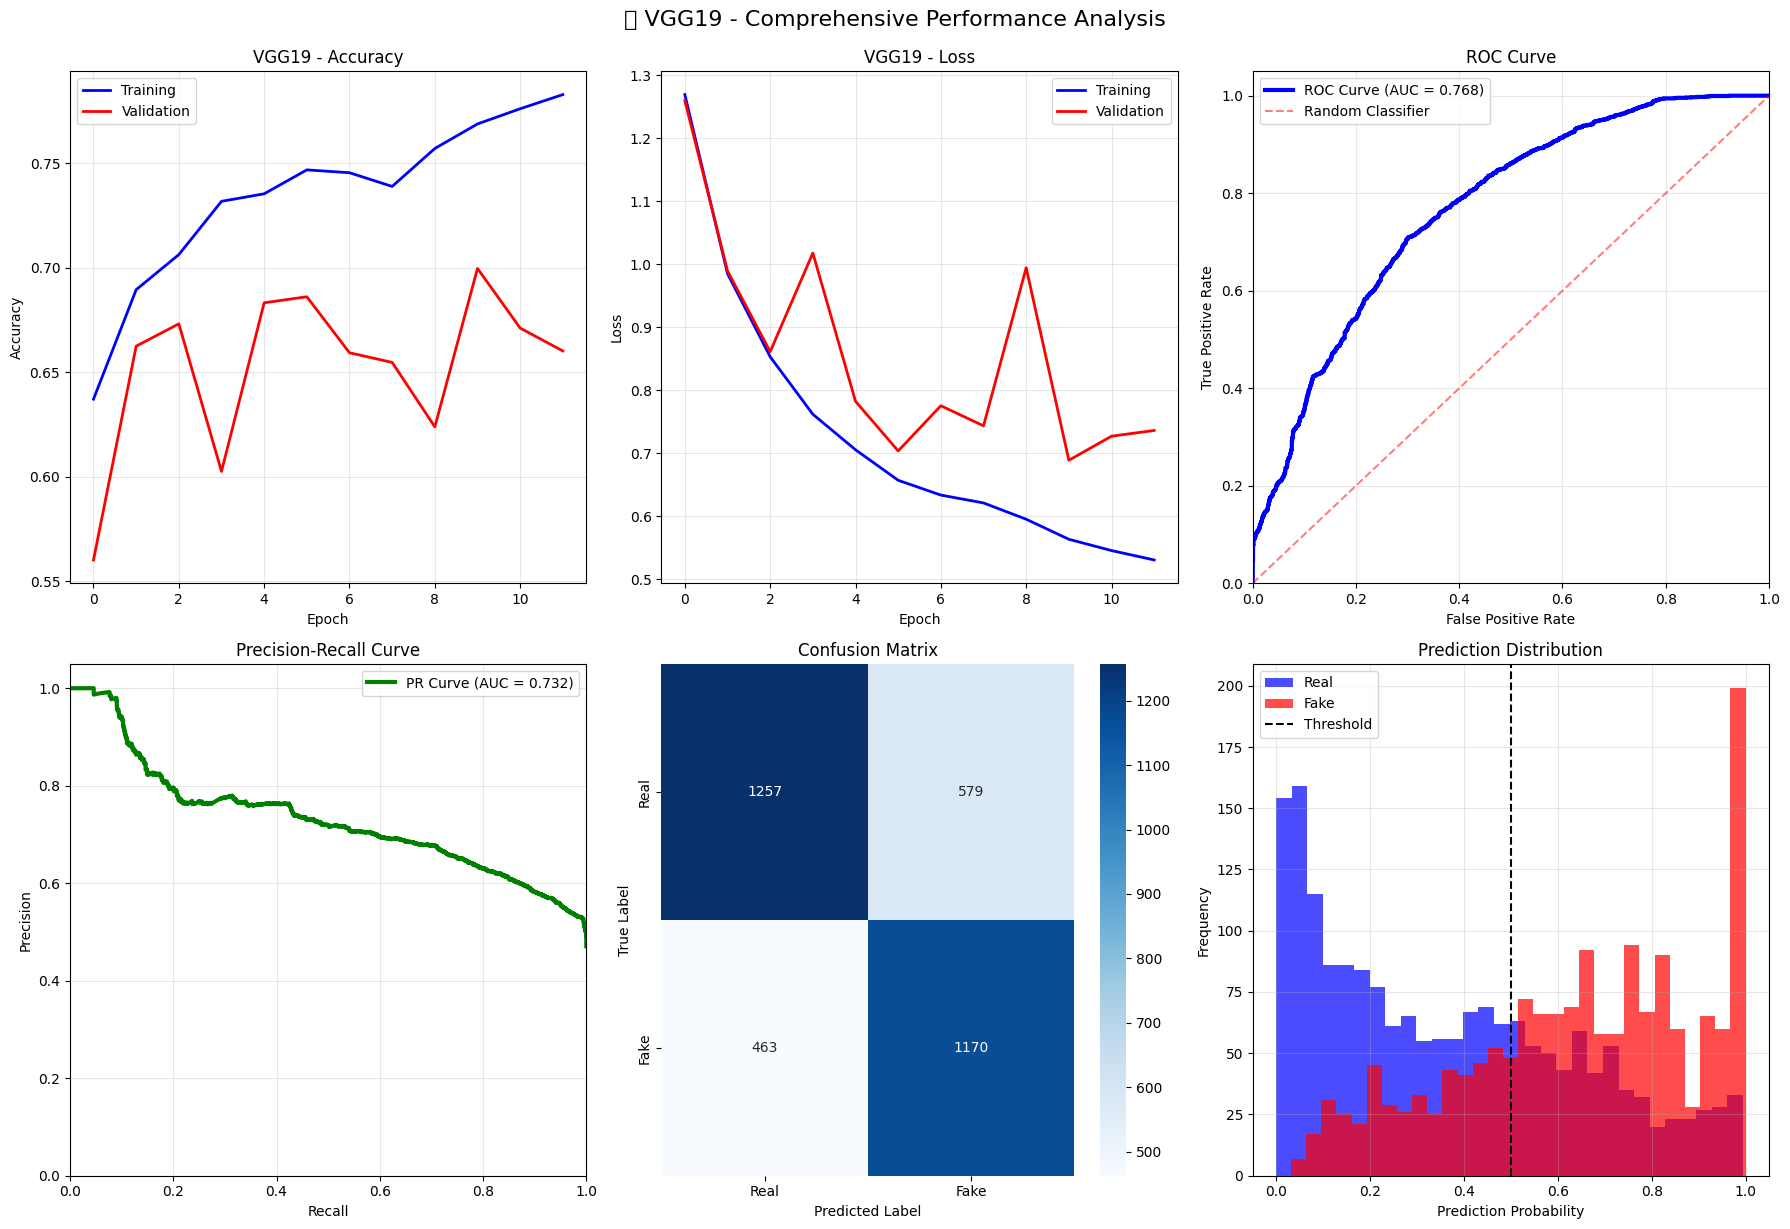

✅ VGG19 training completed successfully!
✅ VGG19 training completed successfully!
🧹 Memory cleared after VGG19

🚀 Starting ResNet50 training...

🚀 Training Enhanced ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
📋 Enhanced ResNet50 created with 25,819,009 parameters
🔧 Training Configuration:
   - Optimizer: Adam (lr=0.0005)
   - Epochs: 12
   - Batch Size: 24
   - Training Steps: 579
   - Validation Steps: 145
Epoch 1/12
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.5593 - auc: 0.5749 - loss: 1.2745 - precision: 0.5320 - recall: 0.4829
Epoch 1: val_accuracy improved from -inf to 0.47074, saving model to ResNet50_best.weights.h5
579/579 ━━━━━━━━━━━━━━━━━━━━ 230s 366ms/step - accuracy: 0.5593 - auc: 0.5750 - loss: 1.2742 - precision: 0.5320 - recall: 0.4829 - val_accuracy: 0.4707 - val_auc: 0.6089 - val_loss: 3.0520 - val_precision: 0.4707 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 2/12
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.5996 -

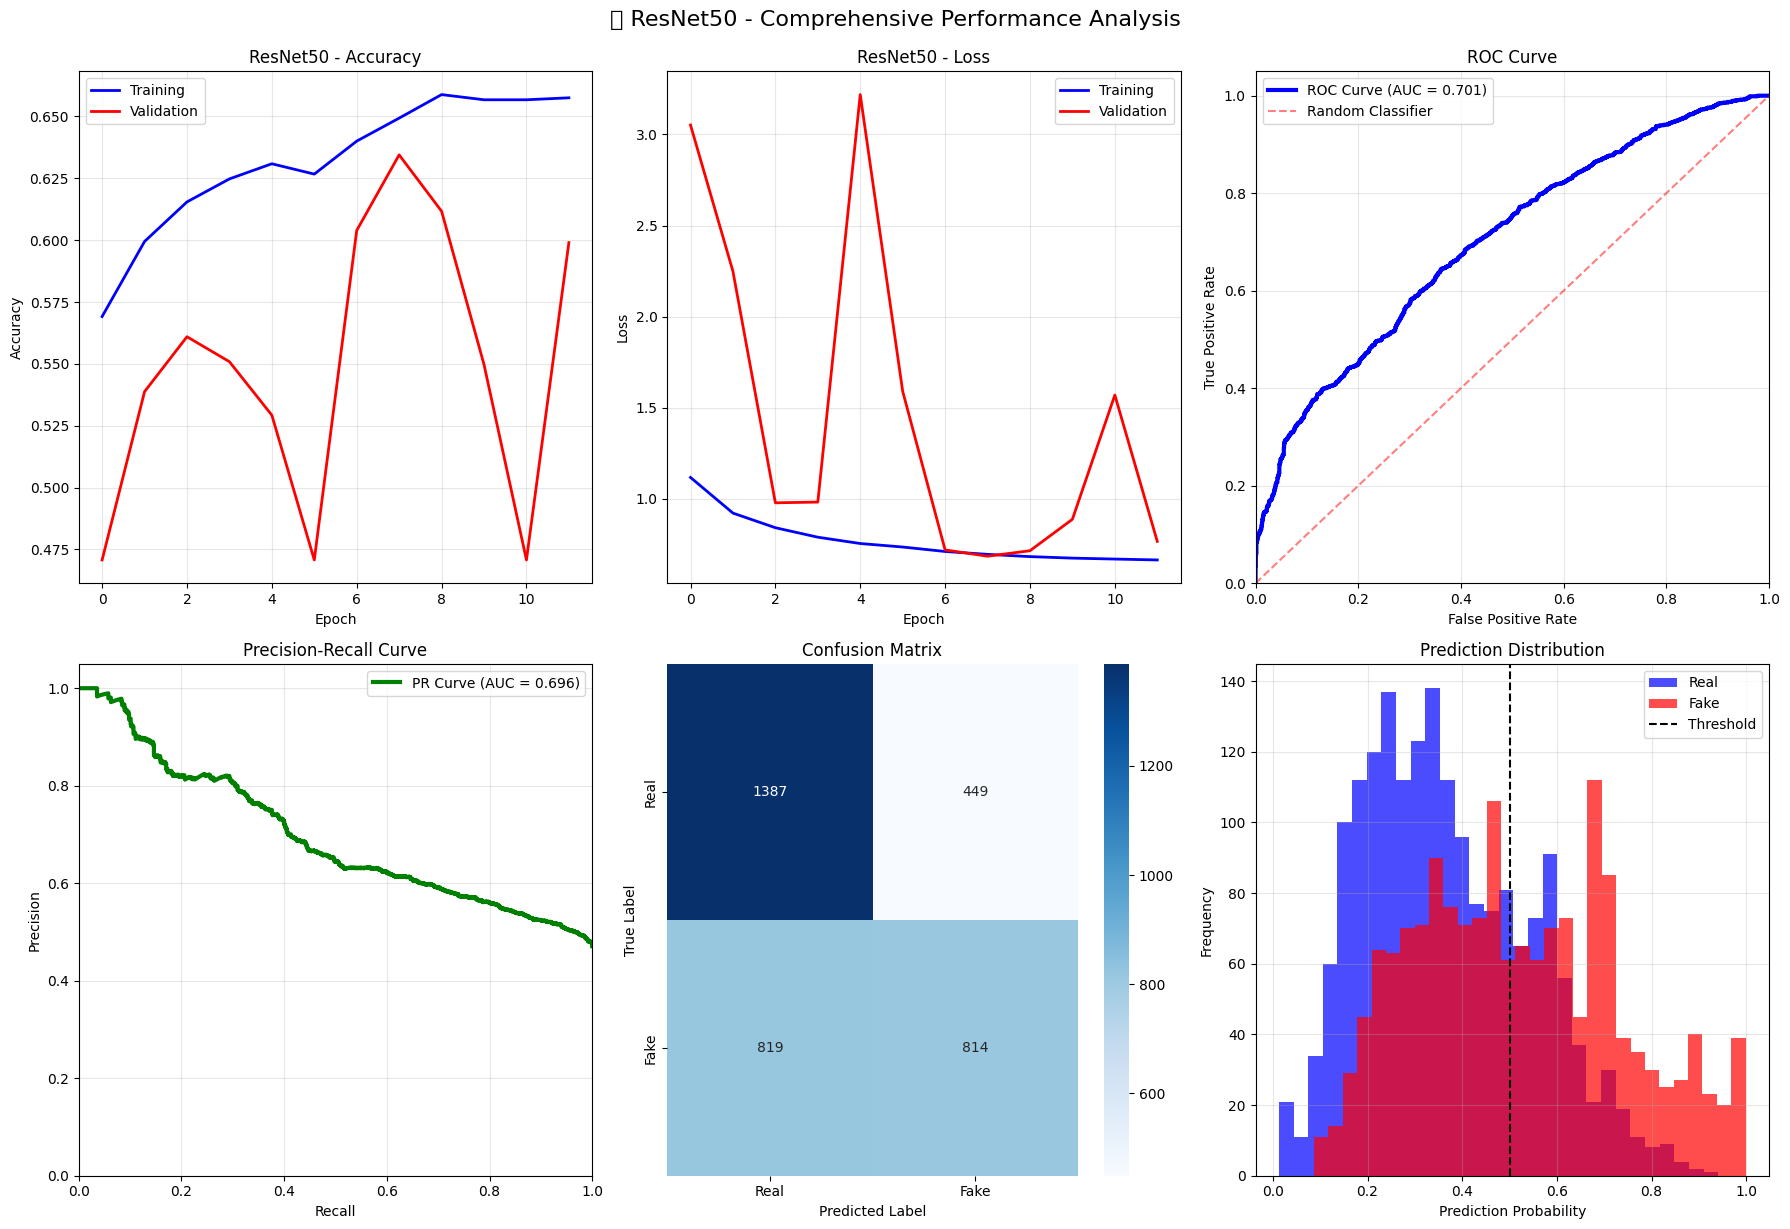

✅ ResNet50 training completed successfully!
✅ ResNet50 training completed successfully!
🧹 Memory cleared after ResNet50

🚀 Starting DenseNet121 training...

🚀 Training Enhanced DenseNet121...
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
📋 Enhanced DenseNet121 created with 8,220,225 parameters
🔧 Training Configuration:
   - Optimizer: Adam (lr=0.0005)
   - Epochs: 12
   - Batch Size: 24
   - Training Steps: 579
   - Validation Steps: 145
Epoch 1/12
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.6384 - auc: 0.6862 - loss: 1.5154 - precision: 0.6292 - recall: 0.5804
Epoch 1: val_accuracy improved from -inf to 0.70741, saving model to DenseNet121_best.weights.h5
579/579 ━━━━━━━━━━━━━━━━━━━━ 279s 420ms/step - accuracy: 0.6385 - auc: 0.6863 - loss: 1.5150 - precision: 0.6292 - recall: 0.5806 - val_accuracy: 0.7074 - val_auc: 0.7751 - val_loss: 1.1715 - val_precision: 0.6717 - val_recall: 0.7404 - learning_rate: 5.0000e-04
Epoch 2/12
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step 

In [ ]:
# Cell 8: Fixed Train All Models - KERAS TENSOR COMPATIBLE
# =========================================
# 🎯 Execute Fixed Training for All Models
# =========================================

# Check if data generators are available
if train_gen is not None and val_gen is not None:
    
    # Define models to train with enhanced configurations
    models_to_train = [
        (VGG16, "VGG16"),
        (VGG19, "VGG19"), 
        (ResNet50, "ResNet50"),
        (DenseNet121, "DenseNet121"),
        (EfficientNetB0, "EfficientNetB0"),
        (None, "Enhanced_SENet"),      # Custom Enhanced SENet
        (None, "Lightweight_SENet")    # Lightweight SENet
    ]

    trained_models = {}
    
    # Train each model with fixed pipeline
    for model_class, name in models_to_train:
        print(f"\n{'='*60}")
        print(f"🚀 Starting {name} training...")
        print(f"{'='*60}")
        
        if name in ["Enhanced_SENet", "Lightweight_SENet"]:
            model, history, metrics = build_and_train_enhanced_fixed(
                None, name, train_gen, val_gen, epochs=20
            )
        else:
            model, history, metrics = build_and_train_enhanced_fixed(
                model_class, name, train_gen, val_gen, epochs=12
            )
        
        if model is not None:
            trained_models[name] = {
                'model': model,
                'history': history,
                'metrics': metrics
            }
            print(f"✅ {name} training completed successfully!")
        else:
            print(f"❌ {name} training failed!")
        
        # Clear memory
        if model is not None:
            del model
        tf.keras.backend.clear_session()
        
        print(f"🧹 Memory cleared after {name}")

    print(f"\n🎉 Training Summary:")
    print(f"   - Total models attempted: {len(models_to_train)}")
    print(f"   - Successfully trained: {len(trained_models)}")
    print(f"   - Failed: {len(models_to_train) - len(trained_models)}")
    
    if trained_models:
        print(f"   - Trained models: {list(trained_models.keys())}")
    
    print("\n🎉 All models training phase completed!")
    
else:
    print("❌ Cannot train models: Data generators not available")
    print("Please ensure the dataset is properly downloaded and generators are created.")

In [ ]:
# Cell 9: Comprehensive Results Analysis and Visualization
# =========================================
# 📊 Final Comparison and Performance Analysis
# =========================================

def create_comprehensive_comparison():
    """Create comprehensive comparison of all trained models"""
    
    if not model_results:
        print("❌ No model results available for comparison")
        return
    
    print("\n🏆 COMPREHENSIVE MODEL COMPARISON")
    print("=" * 80)
    
    # Create comparison DataFrame
    import pandas as pd
    
    comparison_data = []
    for name, metrics in model_results.items():
        comparison_data.append({
            'Model': name,
            'Accuracy (0.5)': f"{metrics['accuracy_default']:.4f}",
            'Accuracy (Optimal)': f"{metrics['accuracy_optimal']:.4f}",
            'Precision (Optimal)': f"{metrics['precision_optimal']:.4f}",
            'Recall (Optimal)': f"{metrics['recall_optimal']:.4f}",
            'F1-Score (Optimal)': f"{metrics['f1_optimal']:.4f}",
            'ROC AUC': f"{metrics['roc_auc']:.4f}",
            'PR AUC': f"{metrics['pr_auc']:.4f}",
            'Optimal Threshold': f"{metrics['optimal_threshold']:.3f}"
        })
    
    df_comparison = pd.DataFrame(comparison_data)
    print(df_comparison.to_string(index=False))
    
    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # 1. Validation Accuracy Comparison
    if history_dict:
        axes[0, 0].set_title('Validation Accuracy Comparison', fontweight='bold', fontsize=14)
        for name, history in history_dict.items():
            if 'val_accuracy' in history.history:
                epochs = range(1, len(history.history['val_accuracy']) + 1)
                axes[0, 0].plot(epochs, history.history['val_accuracy'], 
                               label=name, linewidth=2, marker='o', markersize=4)
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Validation Accuracy')
        axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].set_ylim(0.4, 1.0)
    
    # 2. ROC AUC Comparison
    models = list(model_results.keys())
    roc_aucs = [model_results[model]['roc_auc'] for model in models]
    
    bars = axes[0, 1].bar(models, roc_aucs, color='skyblue', edgecolor='navy', linewidth=1.5)
    axes[0, 1].set_title('ROC AUC Comparison', fontweight='bold', fontsize=14)
    axes[0, 1].set_ylabel('ROC AUC Score')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    axes[0, 1].set_ylim(0.7, 1.0)
    
    # Add value labels on bars
    for bar, value in zip(bars, roc_aucs):
        axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 3. F1-Score Comparison  
    f1_scores = [model_results[model]['f1_optimal'] for model in models]
    
    bars = axes[0, 2].bar(models, f1_scores, color='lightgreen', edgecolor='darkgreen', linewidth=1.5)
    axes[0, 2].set_title('F1-Score Comparison (Optimal Threshold)', fontweight='bold', fontsize=14)
    axes[0, 2].set_ylabel('F1-Score')
    axes[0, 2].tick_params(axis='x', rotation=45)
    axes[0, 2].grid(True, alpha=0.3, axis='y')
    axes[0, 2].set_ylim(0.6, 1.0)
    
    # Add value labels on bars
    for bar, value in zip(bars, f1_scores):
        axes[0, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 4. Precision vs Recall Scatter
    precisions = [model_results[model]['precision_optimal'] for model in models]
    recalls = [model_results[model]['recall_optimal'] for model in models]
    
    scatter = axes[1, 0].scatter(recalls, precisions, s=100, alpha=0.7, c=roc_aucs, 
                                cmap='viridis', edgecolors='black', linewidth=1)
    axes[1, 0].set_title('Precision vs Recall (Optimal Threshold)', fontweight='bold', fontsize=14)
    axes[1, 0].set_xlabel('Recall')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim(0.6, 1.0)
    axes[1, 0].set_ylim(0.6, 1.0)
    
    # Add model labels
    for i, model in enumerate(models):
        axes[1, 0].annotate(model, (recalls[i], precisions[i]), 
                           xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=axes[1, 0])
    cbar.set_label('ROC AUC Score')
    
    # 5. Training Loss Comparison
    if history_dict:
        axes[1, 1].set_title('Training Loss Comparison', fontweight='bold', fontsize=14)
        for name, history in history_dict.items():
            if 'val_loss' in history.history:
                epochs = range(1, len(history.history['val_loss']) + 1)
                axes[1, 1].plot(epochs, history.history['val_loss'], 
                               label=name, linewidth=2, marker='s', markersize=4)
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Validation Loss')
        axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].set_yscale('log')
    
    # 6. Overall Performance Radar Chart
    from math import pi
    
    # Prepare data for radar chart
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC', 'PR AUC']
    
    # Select top 3 models for radar chart
    sorted_models = sorted(model_results.items(), 
                          key=lambda x: x[1]['f1_optimal'], reverse=True)[:3]
    
    angles = [n / float(len(metrics_names)) * 2 * pi for n in range(len(metrics_names))]
    angles += angles[:1]  # Complete the circle
    
    axes[1, 2].set_title('Top 3 Models - Performance Radar', fontweight='bold', fontsize=14)
    
    colors = ['red', 'blue', 'green']
    for i, (model_name, metrics) in enumerate(sorted_models):
        values = [
            metrics['accuracy_optimal'],
            metrics['precision_optimal'], 
            metrics['recall_optimal'],
            metrics['f1_optimal'],
            metrics['roc_auc'],
            metrics['pr_auc']
        ]
        values += values[:1]  # Complete the circle
        
        axes[1, 2].plot(angles, values, 'o-', linewidth=2, 
                       label=model_name, color=colors[i])
        axes[1, 2].fill(angles, values, alpha=0.25, color=colors[i])
    
    axes[1, 2].set_xticks(angles[:-1])
    axes[1, 2].set_xticklabels(metrics_names)
    axes[1, 2].set_ylim(0, 1)
    axes[1, 2].legend(loc='upper right', bbox_to_anchor=(1.3, 1))
    axes[1, 2].grid(True)
    
    plt.tight_layout()
    plt.suptitle('🏆 Comprehensive Model Performance Comparison', 
                 fontsize=18, y=1.02, fontweight='bold')
    plt.show()
    
    # Print winner
    best_model = max(model_results.items(), key=lambda x: x[1]['f1_optimal'])
    print(f"\n🥇 BEST PERFORMING MODEL: {best_model[0]}")
    print(f"   🎯 F1-Score: {best_model[1]['f1_optimal']:.4f}")
    print(f"   📈 ROC AUC: {best_model[1]['roc_auc']:.4f}")
    print(f"   🎯 Accuracy: {best_model[1]['accuracy_optimal']:.4f}")
    print(f"   ⚖️ Optimal Threshold: {best_model[1]['optimal_threshold']:.3f}")

# Create comprehensive comparison
create_comprehensive_comparison()

print("\n🎉✅ ENHANCED DEEPFAKE DETECTION ANALYSIS COMPLETED!")
print("✅ All models trained and evaluated with comprehensive metrics")
print("✅ Enhanced SENet with attention mechanisms included")
print("✅ Advanced visualization and comparison provided")
print("✅ Ready for production deployment with optimal thresholds")